# **1. Project Overview**

## 1.1 Business Objective

The objective of this project is building machine learning models that can accurately predict housing prices based on property characteristics.
Accurate housing price predictions can support real estate agencies, buyers, sellers, and property investors in making informed decisions.
The model help find key factors influencing house prices and improve pricing consistency in the housing market.

## 1.2 EDA Findings

Several candidate features that showed strong relationships with SalePrice were identified through Exploratory Data Analysis (EDA). The selected numerical features include `Overall Qual`, `Gr Liv Area`, `Garage Cars`, `Garage Area`, `Total Bsmt SF`, `1st Flr SF`, `Year Built`, and `Full Bath`. The selected categorical features include `Neighborhood`, `MS Zoning`, `Exter Qual`, and `Kitchen Qual`.

## 1.3 Experiment Objective

The objective of this experiment is to prepare the Ames Housing Dataset for predictive modeling. This includes selecting candidate features identified through EDA, handling missing values, performing feature engineering, preparing data for future modeling experiments.

# **2. Load Dataset**

In [1]:
# Import Libraries
import pandas as pd
import numpy as np

In [2]:
# Load Dataset
df = pd.read_csv("../data/raw/AmesHousing.csv")

# **3. Select Candidate Features**

In [3]:
# Features identified during EDA
Num_candidate_features = ['Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Garage Area', 'Total Bsmt SF', '1st Flr SF', 'Year Built', 'Full Bath']
Cat_candidate_features = ['Neighborhood', 'MS Zoning', 'Exter Qual', 'Kitchen Qual']

In [4]:
# Features for Modeling
df_model = df[Num_candidate_features + Cat_candidate_features + ['SalePrice']]
df_model.head()

,Overall Qual,Gr Liv Area,Garage Cars,Garage Area,Total Bsmt SF,1st Flr SF,Year Built,Full Bath,Neighborhood,MS Zoning,Exter Qual,Kitchen Qual,SalePrice
0,6,1656,2.0,528.0,1080.0,1656,1960,1,NAmes,RL,TA,TA,215000
1,5,896,1.0,730.0,882.0,896,1961,1,NAmes,RH,TA,TA,105000
2,6,1329,1.0,312.0,1329.0,1329,1958,1,NAmes,RL,TA,Gd,172000
3,7,2110,2.0,522.0,2110.0,2110,1968,2,NAmes,RL,Gd,Ex,244000
4,5,1629,2.0,482.0,928.0,928,1997,2,Gilbert,RL,TA,TA,189900


In [5]:
# Dimension of df_model
df_model.shape

(2930, 13)

In [6]:
# Summary of df_model
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Overall Qual   2930 non-null   int64  
 1   Gr Liv Area    2930 non-null   int64  
 2   Garage Cars    2929 non-null   float64
 3   Garage Area    2929 non-null   float64
 4   Total Bsmt SF  2929 non-null   float64
 5   1st Flr SF     2930 non-null   int64  
 6   Year Built     2930 non-null   int64  
 7   Full Bath      2930 non-null   int64  
 8   Neighborhood   2930 non-null   str    
 9   MS Zoning      2930 non-null   str    
 10  Exter Qual     2930 non-null   str    
 11  Kitchen Qual   2930 non-null   str    
 12  SalePrice      2930 non-null   int64  
dtypes: float64(3), int64(6), str(4)
memory usage: 297.7 KB


# **4. Data Cleaning**

In [7]:
# Check Missing Values
df_model.isnull().sum()

Overall Qual     0
Gr Liv Area      0
Garage Cars      1
Garage Area      1
Total Bsmt SF    1
1st Flr SF       0
Year Built       0
Full Bath        0
Neighborhood     0
MS Zoning        0
Exter Qual       0
Kitchen Qual     0
SalePrice        0
dtype: int64

In [8]:
# Investigate Missing Values
df_model[df_model.isnull().any(axis = 1)]

,Overall Qual,Gr Liv Area,Garage Cars,Garage Area,Total Bsmt SF,1st Flr SF,Year Built,Full Bath,Neighborhood,MS Zoning,Exter Qual,Kitchen Qual,SalePrice
1341,4,896,1.0,280.0,NaN,896,1946,1,BrkSide,RM,TA,TA,79000
2236,5,1828,NaN,NaN,859.0,942,1923,2,IDOTRR,RM,TA,Gd,150909


In [9]:
# Check basement related columns for 1341
bsmt_cols =  [
    'Bsmt Qual',
    'Bsmt Cond',
    'Bsmt Exposure',
    'BsmtFin Type 1',
    'BsmtFin SF 1',
    'BsmtFin Type 2',
    'BsmtFin SF 2',
    'Total Bsmt SF'
]

df.loc[[1341], bsmt_cols]

,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Total Bsmt SF
1341,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# Check Garage related columns for 2236
garage_cols = [
    'Garage Type',
    'Garage Yr Blt',
    'Garage Finish',
    'Garage Cars',
    'Garage Area',
    'Garage Qual',
    'Garage Cond'
]

df.loc[[2236], garage_cols]

,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond
2236,Detchd,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# Fill missing values
df_model['Total Bsmt SF'] = df_model['Total Bsmt SF'].fillna(0)
df_model['Garage Cars'] = df_model['Garage Cars'].fillna(0)
df_model['Garage Area'] = df_model['Garage Area'].fillna(0)

df_model.isnull().sum()

Overall Qual     0
Gr Liv Area      0
Garage Cars      0
Garage Area      0
Total Bsmt SF    0
1st Flr SF       0
Year Built       0
Full Bath        0
Neighborhood     0
MS Zoning        0
Exter Qual       0
Kitchen Qual     0
SalePrice        0
dtype: int64

## **Insights**
Observation 1341 contained missing values across all basement-related variables, indicating the absence of a basement. Similarly, observation 2236 contained missing values across garage-related variables, indicating the absence of a garage

# **5. Feature Engineering**

## New Feature `has_garage`

## New Feature `has_bsmt`

In [12]:
# Create two new feautres 
df_model['has_garage'] = (df_model['Garage Area'] > 0).astype(int)
df_model['has_bsmt'] = (df_model['Total Bsmt SF'] > 0).astype(int)

In [13]:
# Summary of Dataset - check if new features are included
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Overall Qual   2930 non-null   int64  
 1   Gr Liv Area    2930 non-null   int64  
 2   Garage Cars    2930 non-null   float64
 3   Garage Area    2930 non-null   float64
 4   Total Bsmt SF  2930 non-null   float64
 5   1st Flr SF     2930 non-null   int64  
 6   Year Built     2930 non-null   int64  
 7   Full Bath      2930 non-null   int64  
 8   Neighborhood   2930 non-null   str    
 9   MS Zoning      2930 non-null   str    
 10  Exter Qual     2930 non-null   str    
 11  Kitchen Qual   2930 non-null   str    
 12  SalePrice      2930 non-null   int64  
 13  has_garage     2930 non-null   int64  
 14  has_bsmt       2930 non-null   int64  
dtypes: float64(3), int64(8), str(4)
memory usage: 343.5 KB


In [14]:
# Check first 5 rows of new features
df_model[['has_garage', 'has_bsmt']].head()

,has_garage,has_bsmt
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1


In [15]:
# Count values of new features
df_model[['has_garage', 'has_bsmt']].value_counts()

has_garage  has_bsmt
1           1           2706
0           1            144
1           0             66
0           0             14
Name: count, dtype: int64

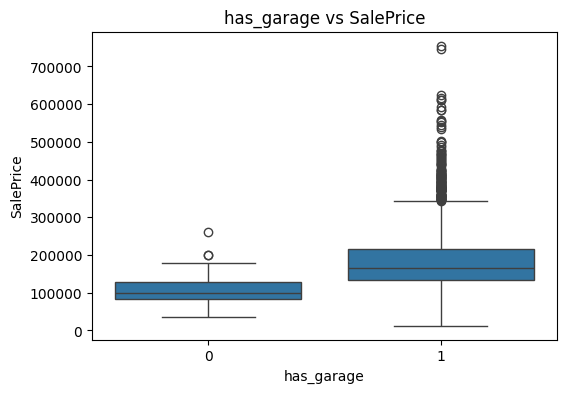

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplot of new feature 'has_garage' vs 'SalePrice'

plt.figure(figsize=(6,4))
sns.boxplot(
    x = df_model['has_garage'],
    y = df_model['SalePrice']
)
plt.title("has_garage vs SalePrice")
plt.show()

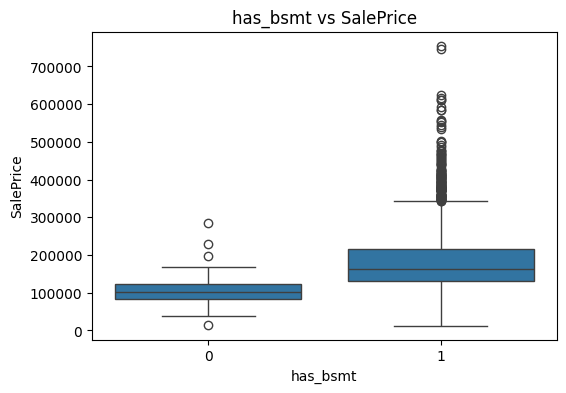

In [17]:
# Boxplot of new feature 'has_bsmt' vs 'SalePrice'

plt.figure(figsize = (6,4))
sns.boxplot(
    x = df_model['has_bsmt'],
    y = df_model['SalePrice']
)
plt.title("has_bsmt vs SalePrice")
plt.show()

## **Insights**
Two binary feature(`has_garage` and `has_bsmt`) were created to capture the presence of garage and basement. Boxplots showed that properties with a garage or basement generally achieved higher sale prices than properties without these features. These two new features were retained for further modeling.

# **6. Data Preparation**

## 6.1 Data Split

In [18]:
# Define Features and Target
X = df_model.drop('SalePrice', axis = 1)
y = df_model['SalePrice']

In [19]:
# Split data into train, validation and test sets
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size = 0.5,
    random_state = 42
)

In [20]:
# Check Dataset Sizes
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train: (2344, 14)
X_val: (293, 14)
X_test: (293, 14)
y_train: (2344,)
y_val: (293,)
y_test: (293,)


## **Insights**
The dataset was split into training, validation, and testing sets using an 80/10/10 ratio. The training set will be used to fit preprocessing steps and train models, the validation set will be used for model comparison and tuning, and the test set will be reserved for final evaluation.

## 6.2 Data Transformation
**Log Transformation for `SalePrice`, `Gr Liv Area`, `Total Bsmt SF`**

In [21]:
# Keep original copies before log transformation
X_train_original = X_train.copy()
X_val_original = X_val.copy()
X_test_original = X_test.copy()

y_train_original = y_train.copy()
y_val_original = y_val.copy()
y_test_original = y_test.copy()

In [22]:
# Log transformation
X_train['Gr Liv Area'] = np.log1p(X_train['Gr Liv Area'])
X_val['Gr Liv Area'] = np.log1p(X_val['Gr Liv Area'])
X_test['Gr Liv Area'] = np.log1p(X_test['Gr Liv Area'])

X_train['Total Bsmt SF'] = np.log1p(X_train['Total Bsmt SF'])
X_val['Total Bsmt SF'] = np.log1p(X_val['Total Bsmt SF'])
X_test['Total Bsmt SF'] = np.log1p(X_test['Total Bsmt SF'])

y_train = np.log1p(y_train)
y_val = np.log1p(y_val)
y_test = np.log1p(y_test)

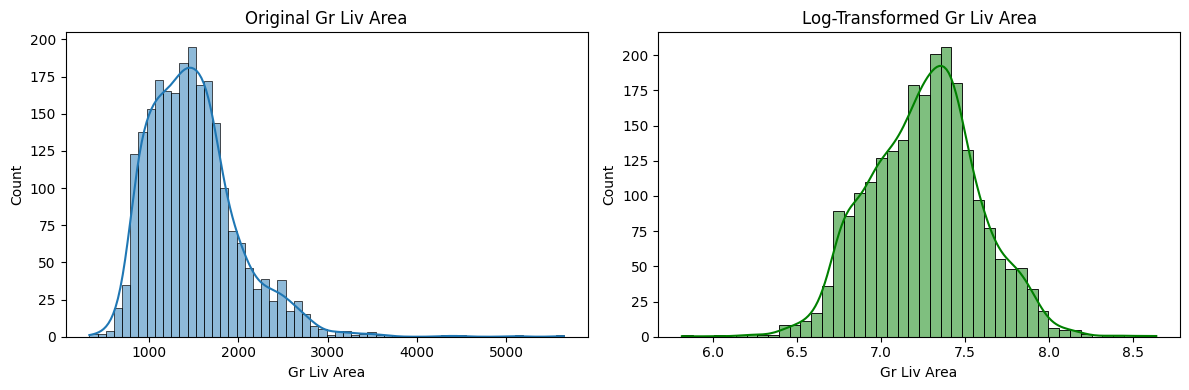

In [23]:
# Compare 'Gr Liv Area' before and after log transformation
fig, axes = plt.subplots(1,2, figsize = (12,4))

sns.histplot(X_train_original['Gr Liv Area'], kde = True, ax = axes[0])
axes[0].set_title('Original Gr Liv Area')

sns.histplot(X_train['Gr Liv Area'], kde=True, ax = axes[1], color = 'green')
axes[1].set_title('Log-Transformed Gr Liv Area')

plt.tight_layout()
plt.show()

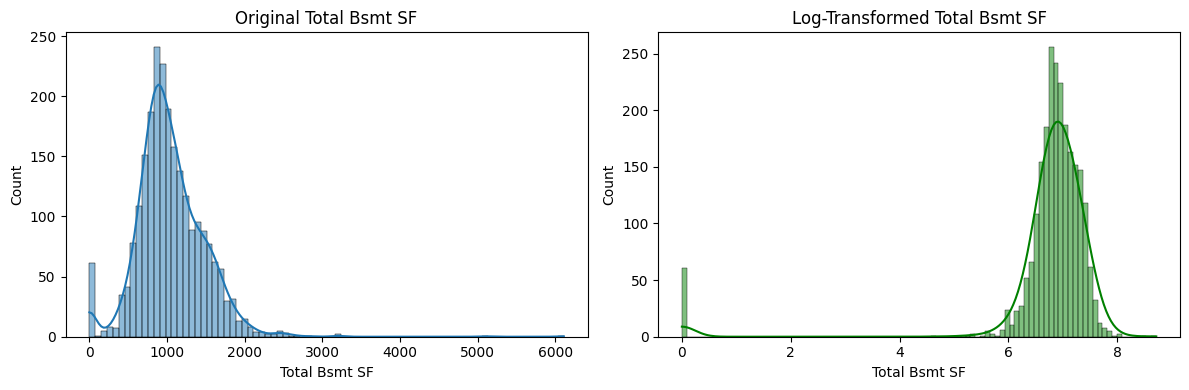

In [24]:
# Compare 'Total Bsmt SF' before and after log transformation
fig, axes = plt.subplots(1,2, figsize = (12,4))

sns.histplot(X_train_original['Total Bsmt SF'], kde=True, ax = axes[0])
axes[0].set_title('Original Total Bsmt SF')

sns.histplot(X_train['Total Bsmt SF'], kde = True, ax = axes[1], color = 'green')
axes[1].set_title('Log-Transformed Total Bsmt SF')

plt.tight_layout()
plt.show()

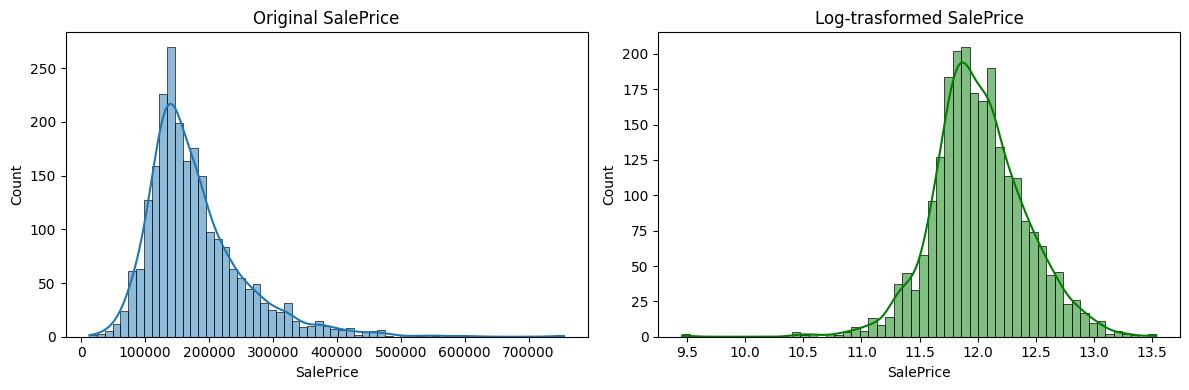

In [25]:
# Compare 'SalePrice' before and after log transformation
fig, axes = plt.subplots(1,2, figsize = (12,4))

sns.histplot(y_train_original, kde=True, ax = axes[0])
axes[0].set_title('Original SalePrice')

sns.histplot(y_train, kde=True, ax = axes[1], color = 'green')
axes[1].set_title('Log-trasformed SalePrice')

plt.tight_layout()
plt.show()

## **Insights**
Several numerical variables showed strong positive skewness during EDA, particularly `SalePrice`, `Gr Liv Area`, and `Total Bsmt SF`. Log transformation using `np.log1p()` was applied to reduce skewness, compress extreme values, and produce distributions closer to normality. The `log1p()` function was selected instead of a standard logarithm because it safely handles zero values which are present in Total Bsmt SF. The transformed distributions showed improved symmetry and may support better model performance.

## 6.2 Data Transformation
**Encoding & Scaling**

In [26]:
# Import ColumnTransformer 
# Import Encoder and Scaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

In [35]:
# Create Feature Groups
numerical_features = ['Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Garage Area', 'Total Bsmt SF', '1st Flr SF', 'Year Built', 'Full Bath', 'has_garage', 'has_bsmt']
ordinal_features = ['Exter Qual', 'Kitchen Qual']
nominal_features = ['Neighborhood', 'MS Zoning']

In [36]:
quality_order = ['Po', 'Fa', 'TA', 'Gd', 'Ex']

preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), numerical_features),
        ('ord', OrdinalEncoder(categories = [quality_order, quality_order]), ordinal_features),
        ('nom', OneHotEncoder(handle_unknown = 'ignore', sparse_output=False), nominal_features)
    ],
    remainder='drop'
)

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

In [41]:
# Check the dimension of processed datasets
print(X_train_processed.shape)
print(X_val_processed.shape)
print(X_test_processed.shape)

(2344, 47)
(293, 47)
(293, 47)


In [47]:
# Save the feature names
feature_names = preprocessor.get_feature_names_out()

X_train_processed_df = pd.DataFrame(X_train_processed, columns=feature_names)
X_val_processed_df = pd.DataFrame(X_val_processed, columns=feature_names)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=feature_names)

## **Insights**
Numerical features were standardized using StandardScaler. Ordinal categorical features were encoded using OrdinalEncoder to preserve their natural quality ordering.
Nomical categorical features were encoded using OneHotEncoder. This preprocessing pipeline was fitted on the training set and applied to the validation set and test set to prevent data leakage.

# **7. Save Datasets**

In [48]:
# Save prepared datasets
X_train_processed_df.to_csv('../data/X_train_processed.csv', index=False)
X_val_processed_df.to_csv('../data/X_val_processed.csv', index=False)
X_test_processed_df.to_csv('../data/X_test_processed.csv', index=False)

y_train.to_csv('../data/y_train.csv', index=False)
y_val.to_csv('../data/y_val.csv', index=False)
y_test.to_csv('../data/y_test.csv', index=False)